# Notebook 7: CBRNN (CNN + BiLSTM) with ESM-2 Embeddings

The BiLSTM and Transformer notebooks were both about *long-range* context,
Letting a residue see far-away parts of the sequence. But secondary
structure also has strong local patterns: an α-helix has a roughly
3.6-residue periodicity, and short local motifs often signal the start or
end of a structural element. A plain BiLSTM has to infer these local motifs
itself from the raw per-residue input; a 1D convolution is architecturally
built to detect exactly this kind of fixed-width local pattern, regardless of
where in the sequence it occurs.

This notebook builds a CBRNN (Convolutional + Bidirectional Recurrent
Neural Network). CNN layers first, extracting local motif features from the
ESM-2 embeddings, feeding into a BiLSTM that then combines those motif
features with long-range context. This is deliberately the same pattern used
by Porter6/DeepPredict, the state-of-the-art PSSP systems: a
pretrained PLM supplies rich per-residue features, and a CNN+BiRNN head
extracts local and long-range structure from them.

### Architecture
- Input: ESM-2 embeddings (identical extraction/caching as notebook 6)
- 2 stacked 1D conv layers (kernel sizes 7 then 5): local motif detectors
- BiLSTM (2 layers × 128 hidden units × 2 directions) on top of the conv
  output: long-range context, same as notebooks 4 and 6
- Classifier: Linear(256 → 3)


In [2]:
import os
import pickle
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

df = pd.read_csv("protein_sequences_ss_3.csv")
print(f"Loaded {len(df)} proteins")


Device: cuda
Loaded 599 proteins


In [3]:
# ── Load a frozen, pretrained ESM-2 model (identical to notebook 6) ───────────
MODEL_NAME = "facebook/esm2_t12_35M_UR50D"   # 35M params, 480-dim embeddings

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
esm_model = AutoModel.from_pretrained(MODEL_NAME).to(device)
esm_model.eval()

for p in esm_model.parameters():
    p.requires_grad = False

EMBED_DIM = esm_model.config.hidden_size
n_params  = sum(p.numel() for p in esm_model.parameters())
print(f"Loaded {MODEL_NAME}")
print(f"Embedding dimension: {EMBED_DIM} | Parameters: {n_params:,} (frozen)")


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded facebook/esm2_t12_35M_UR50D
Embedding dimension: 480 | Parameters: 33,500,401 (frozen)


In [4]:
# ── Label encoder + protein-level split (identical to notebooks 4 and 6) ─────
le = LabelEncoder()
le.fit(["H", "E", "C"])
print("Classes:", le.classes_)

protein_ids = df.index.tolist()
train_ids, test_ids = train_test_split(protein_ids, test_size=0.2, random_state=42)
train_df = df.iloc[train_ids].reset_index(drop=True)
test_df  = df.iloc[test_ids].reset_index(drop=True)
print(f"Train: {len(train_df)} proteins | Test: {len(test_df)} proteins")


Classes: ['C' 'E' 'H']
Train: 479 proteins | Test: 120 proteins


In [5]:
# ── Extract ESM-2 embeddings once, cache to disk ──────────────────────────────
CACHE_PATH = "esm2_embeddings.pkl"

@torch.no_grad()
def get_esm2_embedding(sequence):
    inputs  = tokenizer(sequence, return_tensors="pt").to(device)
    outputs = esm_model(**inputs)
    return outputs.last_hidden_state[0, 1:-1, :].cpu().numpy()

if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, "rb") as f:
        embedding_cache = pickle.load(f)
    print(f"Loaded {len(embedding_cache)} cached embeddings from {CACHE_PATH}")
else:
    embedding_cache = {}

for _, row in tqdm(df.iterrows(), total=len(df), desc="Extracting ESM-2 embeddings"):
    pid = row["pdb_id"]
    if pid not in embedding_cache:
        emb = get_esm2_embedding(row["sequence"])
        assert emb.shape[0] == len(row["sequence"]), f"Length mismatch for {pid}"
        embedding_cache[pid] = emb

with open(CACHE_PATH, "wb") as f:
    pickle.dump(embedding_cache, f)

print(f"Cached embeddings for {len(embedding_cache)} proteins → {CACHE_PATH}")


Loaded 599 cached embeddings from esm2_embeddings.pkl


Extracting ESM-2 embeddings:   0%|          | 0/599 [00:00<?, ?it/s]

Cached embeddings for 599 proteins → esm2_embeddings.pkl


In [6]:
# ── Dataset (identical to notebook 6) ─────────────────────────────────────────
class ProteinDataset(Dataset):
    def __init__(self, df):
        self.samples = []
        for _, row in df.iterrows():
            x = torch.tensor(embedding_cache[row["pdb_id"]], dtype=torch.float32)
            y = torch.tensor(
                le.transform(list(row["secondary_structure"])),
                dtype=torch.long
            )
            self.samples.append((x, y))

    def __len__(self):             return len(self.samples)
    def __getitem__(self, idx):    return self.samples[idx]


In [7]:
# ── Collate: pad variable-length sequences to batch (identical to notebook 6) ─
def collate_fn(batch):
    xs, ys  = zip(*batch)
    lengths = [x.shape[0] for x in xs]
    max_len = max(lengths)

    x_pad = torch.zeros(len(xs), max_len, EMBED_DIM)
    y_pad = torch.full((len(xs), max_len), fill_value=-1, dtype=torch.long)

    for i, (x, y) in enumerate(zip(xs, ys)):
        x_pad[i, :x.shape[0]] = x
        y_pad[i, :y.shape[0]] = y

    return x_pad, y_pad, lengths


In [8]:
# ── Model: CBRNN = 1D CNN (local motifs) → BiLSTM (long-range context) ────────
class CBRNN(nn.Module):
    def __init__(self, input_size=EMBED_DIM, conv_channels=128, kernel_sizes=(7, 5),
                 lstm_hidden=128, lstm_layers=2, num_classes=3, dropout=0.3):
        super().__init__()

        conv_layers = []
        in_ch = input_size
        for k in kernel_sizes:
            conv_layers += [
                nn.Conv1d(in_ch, conv_channels, kernel_size=k, padding=k // 2),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            in_ch = conv_channels
        self.conv = nn.Sequential(*conv_layers)

        self.bilstm = nn.LSTM(
            input_size=conv_channels,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )
        self.classifier = nn.Linear(lstm_hidden * 2, num_classes)

    def forward(self, x):
        x = x.transpose(1, 2)          # (batch, input_size, seq_len) for Conv1d
        x = self.conv(x)               # (batch, conv_channels, seq_len)
        x = x.transpose(1, 2)          # back to (batch, seq_len, conv_channels)
        out, _ = self.bilstm(x)        # (batch, seq_len, lstm_hidden*2)
        return self.classifier(out)    # (batch, seq_len, num_classes)


In [9]:
# ── DataLoaders ────────────────────────────────────────────────────────────────
train_dataset = ProteinDataset(train_df)
test_dataset  = ProteinDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, collate_fn=collate_fn)


In [10]:
# ── Training utilities ─────────────────────────────────────────────────────────
model     = CBRNN().to(device)
criterion = nn.CrossEntropyLoss(ignore_index=-1)   # -1 = padded positions
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

def train_epoch(model, loader):
    model.train()
    total = 0
    for x, y, _ in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x).view(-1, 3), y.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
    return total / len(loader)

def compute_loss(model, loader):
    model.eval()
    total = 0
    with torch.no_grad():
        for x, y, _ in loader:
            x, y = x.to(device), y.to(device)
            total += criterion(model(x).view(-1, 3), y.view(-1)).item()
    return total / len(loader)

def evaluate(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y, lengths in loader:
            x, y = x.to(device), y.to(device)
            out  = model(x).argmax(dim=-1)
            for i, l in enumerate(lengths):
                preds.extend(out[i, :l].cpu().numpy())
                labels.extend(y[i,  :l].cpu().numpy())
    return np.array(preds), np.array(labels)


Trainable parameters: 1,172,483


In [11]:
# ── Training loop with early stopping (same protocol as notebooks 4 and 6) ───
NUM_EPOCHS    = 40
PATIENCE      = 5
best_val_loss = float("inf")
patience_ctr  = 0

train_losses, val_losses, val_accs = [], [], []

for epoch in range(NUM_EPOCHS):
    tr_loss = train_epoch(model, train_loader)

    if (epoch + 1) % 5 == 0:
        vl_loss           = compute_loss(model, test_loader)
        preds, labels_arr = evaluate(model, test_loader)
        acc               = (preds == labels_arr).mean()

        train_losses.append(tr_loss)
        val_losses.append(vl_loss)
        val_accs.append(acc)

        print(f"Epoch {epoch+1:02d} | Train Loss: {tr_loss:.4f} | "
              f"Val Loss: {vl_loss:.4f} | Accuracy: {acc:.4f}")

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            torch.save(model.state_dict(), "cbrnn_esm2_best.pt")
            patience_ctr  = 0
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f"\nEarly stopping at epoch {epoch+1}.")
                break

print("\nTraining complete. Best model saved to cbrnn_esm2_best.pt")


Epoch 05 | Train Loss: 0.4964 | Val Loss: 0.4950 | Accuracy: 0.7983
Epoch 10 | Train Loss: 0.4285 | Val Loss: 0.4806 | Accuracy: 0.8054
Epoch 15 | Train Loss: 0.3673 | Val Loss: 0.5235 | Accuracy: 0.8036
Epoch 20 | Train Loss: 0.3130 | Val Loss: 0.5421 | Accuracy: 0.8008
Epoch 25 | Train Loss: 0.2520 | Val Loss: 0.6427 | Accuracy: 0.7949
Epoch 30 | Train Loss: 0.2078 | Val Loss: 0.6928 | Accuracy: 0.7944
Epoch 35 | Train Loss: 0.1811 | Val Loss: 0.7248 | Accuracy: 0.7913

Early stopping at epoch 35.

Training complete. Best model saved to cbrnn_esm2_best.pt


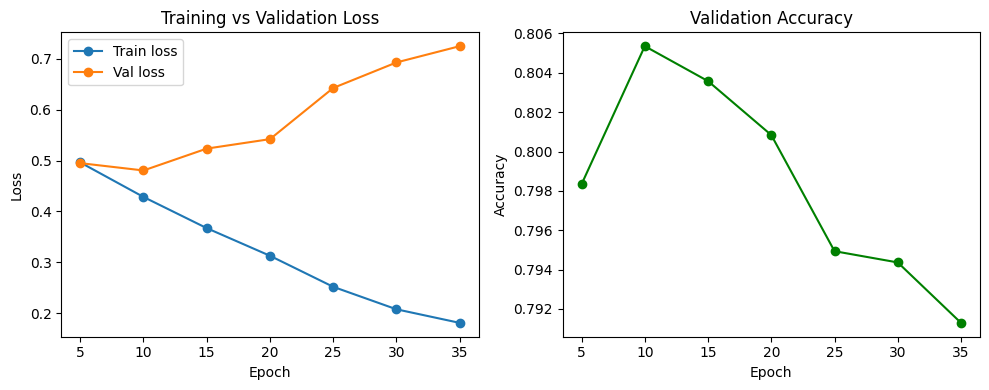

In [12]:
# ── Learning curves ────────────────────────────────────────────────────────────
epochs_logged = list(range(5, 5 * len(train_losses) + 1, 5))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(epochs_logged, train_losses, label="Train loss", marker="o")
ax1.plot(epochs_logged, val_losses,   label="Val loss",   marker="o")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("Training vs Validation Loss")
ax1.legend()

ax2.plot(epochs_logged, val_accs, color="green", marker="o")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_title("Validation Accuracy")

plt.tight_layout()
plt.savefig("learning_curves_cbrnn_esm2.png", dpi=150)
plt.show()


In [13]:
# ── Final evaluation (best model) ─────────────────────────────────────────────
model.load_state_dict(torch.load("cbrnn_esm2_best.pt", map_location=device))

preds, labels_arr = evaluate(model, test_loader)
print(classification_report(labels_arr, preds, target_names=le.classes_))


/tmp/ipykernel_2248/1169736839.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("cbrnn_esm2_best.pt", map_location=device))


              precision    recall  f1-score   support

           C       0.76      0.79      0.77     12974
           E       0.81      0.72      0.76      6537
           H       0.85      0.86      0.86     13698

    accuracy                           0.81     33209
   macro avg       0.81      0.79      0.80     33209
weighted avg       0.81      0.81      0.81     33209



### Comparing across the whole project

At this point there's a full ablation matrix worth laying side by side:

| Notebook | Encoding | Architecture | What it isolates |
|---|---|---|---|
| 2 | One-hot | RF / XGBoost, 15-residue window | Baseline, no biochemical similarity |
| 3 | BLOSUM62 | RF / XGBoost, 15-residue window | Encoding richness, still local-only |
| 4 | BLOSUM62 | BiLSTM | Long-range context, cheap encoding |
| 5 | BLOSUM62 | Transformer (from scratch) | Direct long-range connections vs recurrence |
| 6 | ESM-2 | BiLSTM | Pretrained representation, same architecture as 4 |
| 7 | ESM-2 | CNN → BiLSTM (CBRNN) | Local motif detection *and* long-range context, on top of the best encoding |

If notebook 7 beats notebook 6, the CNN front-end is adding something the
BiLSTM alone couldn't extract from ESM-2 embeddings — local motif patterns
distinct from long-range dependencies. If it's roughly tied, that's evidence
ESM-2's embeddings already encode local motif information well enough that
an explicit CNN stage is redundant on top of it — worth checking against the
per-class breakdown (H is a strong local/periodic pattern; E's difficulty has
always been about distance, not locality) rather than just overall accuracy.

### If you want to keep going
- Try wider/multiple kernel sizes in parallel (e.g. 3, 5, 9 concatenated) —
  an inception-style multi-scale CNN front end.
- Add explicit padding masking to the CNN using the `lengths` list, to
  remove the boundary-leakage caveat above.
- Full CASP-style benchmark comparison against Porter6/NetSurfP-3.0 numbers
  reported in the literature, to see how close a from-scratch project gets
  to a mature, heavily-tuned system.
